# Three-class Pointwise MLP · 10 presynaptic embeddings + post · 5 folds

Classes: BasketFam; nonBasketInhibitory (BipFam, MartFam, NglFam); Excitatory (pyramidal, thalamocortical). Same original folds 0–4 and pre + post inputs. These are new trainings with a three-output classifier, using the original 30 epochs and hyperparameters. Fold means weight folds equally; standard deviation uses ddof=1. Validation and testing share the original held-out split. Run all cells once completed fold results are available.


Running folds appear with best-so-far metrics. Completed-fold aggregates exclude unfinished runs. Outputs are a saved snapshot; use Run All to refresh.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'scripts/train_gnn.py').is_file())
RESULT_ROOT = ROOT / 'results/presynaptic/cave_skeletons_pre_post/k10/conf0.7/three_class'
RUN = 'gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_n10_mixed16_sampled_pre_post'
MODEL = 'Pointwise MLP · 10 presynaptic embeddings + post · 5 folds'
FOLDS = range(5)
COLORS = plt.get_cmap('tab10').colors[:5]
pd.options.display.float_format = '{:.4f}'.format


## Fold status and best-checkpoint performance

Each fold shows its latest recorded epoch and whether final results are available. Running folds use best_metrics.json; completed folds use the final result JSON. Aggregates include completed folds only.

In [2]:
def read_metrics(path):
    try:
        return json.loads(path.read_text())
    except (FileNotFoundError, json.JSONDecodeError):
        return None  # A training job may currently be writing this file.

status, rows, payloads, curves = [], [], {}, {}
metric_columns = [f'{scope}_{metric}' for scope in ('window', 'cell')
                  for metric in ('accuracy', 'balanced_accuracy', 'macro_precision', 'macro_f1')]
for fold in FOLDS:
    directory = RESULT_ROOT / f'fold{fold}' / 'pre_post'
    path = directory / f'{RUN}_fold{fold}.json'
    run_directory = directory / f'{RUN}_fold{fold}'
    curve_path = run_directory / 'epoch_metrics.csv'
    if curve_path.exists():
        try:
            frame = pd.read_csv(curve_path).dropna(subset=['epoch']).sort_values('epoch')
            if not frame.empty:
                curves[fold] = frame
        except (pd.errors.EmptyDataError, pd.errors.ParserError):
            pass
    payload = read_metrics(path)
    complete = payload is not None
    if payload is None:
        payload = read_metrics(run_directory / 'best_metrics.json')
    state = 'complete' if complete else ('in progress (best so far)' if payload else
            'in progress (epoch metrics)' if fold in curves else 'awaiting metrics')
    status.append(dict(fold=fold, status=state,
                       latest_epoch=int(curves[fold].epoch.max()) if fold in curves else None,
                       epochs_recorded=len(curves[fold]) if fold in curves else 0,
                       result=str((path if complete else run_directory).relative_to(ROOT))))
    if payload is None:
        continue
    if complete:
        assert payload['fold_index'] == fold, f'Fold mismatch: {path}'
    payload['best_epoch'] = payload.get('best_epoch', payload.get('epoch'))
    payloads[fold] = payload
    row = dict(fold=fold, complete=complete, best_epoch=payload['best_epoch'])
    for scope, key in [('window', 'window_test_metrics'), ('cell', 'test_metrics')]:
        for metric in ('accuracy', 'balanced_accuracy', 'macro_precision', 'macro_f1'):
            row[f'{scope}_{metric}'] = payload[key][metric]
        row[f'{scope}_support'] = np.asarray(payload[key]['confusion_matrix']).sum()
    rows.append(row)
print('Snapshot refreshed:', pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'))
display(pd.DataFrame(status))
summary = pd.DataFrame(rows, columns=['fold', 'complete', 'best_epoch', *metric_columns,
                                     'window_support', 'cell_support']).set_index('fold').sort_index()
if not summary.empty:
    print('Saved best-checkpoint metrics; complete=False means provisional.')
    display(summary)
completed = summary[summary.complete.eq(True)]
print(f'Completed folds: {len(completed)}/5. Rerun all cells to refresh this snapshot.')
if not completed.empty:
    aggregate = completed[metric_columns].agg(['count', 'mean', 'std', 'min', 'max']).T
    aggregate.index.name = 'metric'
    print('Aggregate uses completed folds only (sample standard deviation, ddof=1).')
    display(aggregate)
else:
    print('Awaiting completed folds; training curves and available best-so-far metrics are shown below.')


Snapshot refreshed: 2026-10-09 14:17:26


,fold,status,latest_epoch,epochs_recorded,result
0,0,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
1,1,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
2,2,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
3,3,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
4,4,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...


Saved best-checkpoint metrics; complete=False means provisional.


,complete,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,window_support,cell_support
fold,,,,,,,,,,,,
0,True,29,0.9066,0.8951,0.9103,0.9015,0.9666,0.9149,0.9863,0.9442,293953,359
1,True,26,0.9074,0.9004,0.9028,0.9016,0.9748,0.9490,0.9737,0.9599,303352,357
2,True,27,0.8980,0.8865,0.8937,0.8895,0.9774,0.9380,0.9659,0.9503,288259,354
3,True,25,0.8857,0.8743,0.8793,0.8765,0.9717,0.9306,0.9793,0.9507,297192,353
4,True,29,0.9056,0.8870,0.9033,0.8940,0.9543,0.8788,0.9728,0.9120,290232,350


Completed folds: 5/5. Rerun all cells to refresh this snapshot.
Aggregate uses completed folds only (sample standard deviation, ddof=1).


,count,mean,std,min,max
metric,,,,,
window_accuracy,5.0000,0.9007,0.0092,0.8857,0.9074
window_balanced_accuracy,5.0000,0.8887,0.0099,0.8743,0.9004
window_macro_precision,5.0000,0.8979,0.0120,0.8793,0.9103
window_macro_f1,5.0000,0.8926,0.0104,0.8765,0.9016
cell_accuracy,5.0000,0.9689,0.0091,0.9543,0.9774
cell_balanced_accuracy,5.0000,0.9223,0.0273,0.8788,0.9490
cell_macro_precision,5.0000,0.9756,0.0076,0.9659,0.9863
cell_macro_f1,5.0000,0.9434,0.0184,0.9120,0.9599


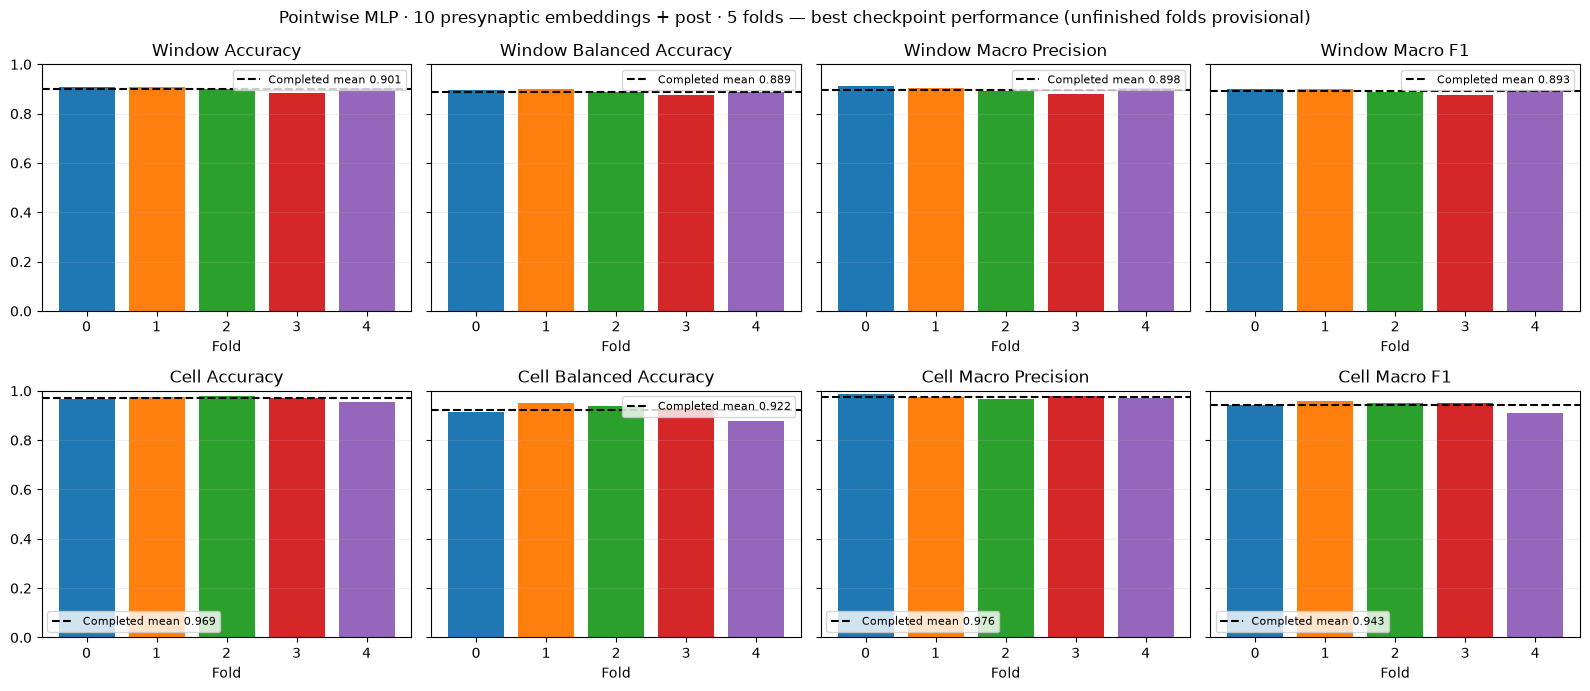

In [3]:
if payloads:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
    for ax, metric in zip(axes.flat, metric_columns):
        values = summary[metric]
        ax.bar(values.index, values, color=[COLORS[f] for f in values.index])
        if not completed.empty:
            mean = completed[metric].mean()
            ax.axhline(mean, color='black', linestyle='--', label=f'Completed mean {mean:.3f}')
        ax.set(title=metric.replace('_', ' ').title(), xlabel='Fold', xticks=list(FOLDS), ylim=(0, 1))
        ax.grid(axis='y', alpha=.2)
        ax.legend(fontsize=8)
    fig.suptitle(MODEL + ' — best checkpoint performance (unfinished folds provisional)')
    fig.tight_layout()
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')

## Training trajectories

Separate lines show each fold. Dots mark the saved best epoch on held-out F1 curves; these epochs can differ across folds.

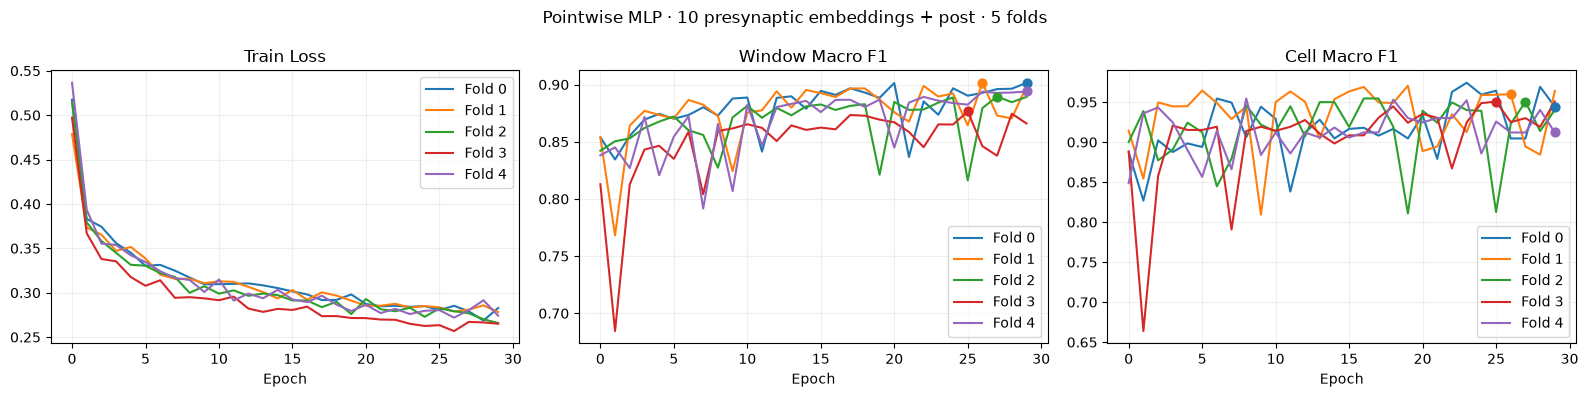

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['train_loss', 'window_macro_f1', 'cell_macro_f1']):
    for fold, frame in curves.items():
        ax.plot(frame.epoch, frame[metric], color=COLORS[fold], label=f'Fold {fold}')
        if fold in payloads and metric != 'train_loss':
            best = frame[frame.epoch == payloads[fold]['best_epoch']]
            ax.scatter(best.epoch, best[metric], color=COLORS[fold], s=40, zorder=3)
    ax.set(title=metric.replace('_', ' ').title(), xlabel='Epoch')
    ax.grid(alpha=.2)
    if ax.lines:
        ax.legend()
fig.suptitle(MODEL)
fig.tight_layout()
plt.show()


## Per-class recall and support

Running folds show provisional best-checkpoint results. Per-class mean/std below includes all displayed folds; support counts explain rare-class variability.

Window recall by fold


fold,0,1,2,3,4,mean,std
BasketFam,0.9436,0.9518,0.9387,0.9324,0.9456,0.9424,0.0073
Excitatory,0.9485,0.9213,0.9359,0.9176,0.9446,0.9336,0.0137
nonBasketInhibitory,0.7933,0.8281,0.7851,0.7729,0.7709,0.7900,0.0231


Window support by fold


,0,1,2,3,4
BasketFam,87067,90954,90820,92848,96772
Excitatory,130250,137456,123390,129301,127738
nonBasketInhibitory,76636,74942,74049,75043,65722


Cell recall by fold


fold,0,1,2,3,4,mean,std
BasketFam,1.0000,1.0000,0.9697,1.0000,1.0000,0.9939,0.0136
Excitatory,1.0000,0.9928,1.0000,1.0000,1.0000,0.9986,0.0032
nonBasketInhibitory,0.7447,0.8542,0.8444,0.7917,0.6364,0.7743,0.0887


Cell support by fold


,0,1,2,3,4
BasketFam,33,32,33,32,33
Excitatory,279,277,276,273,273
nonBasketInhibitory,47,48,45,48,44


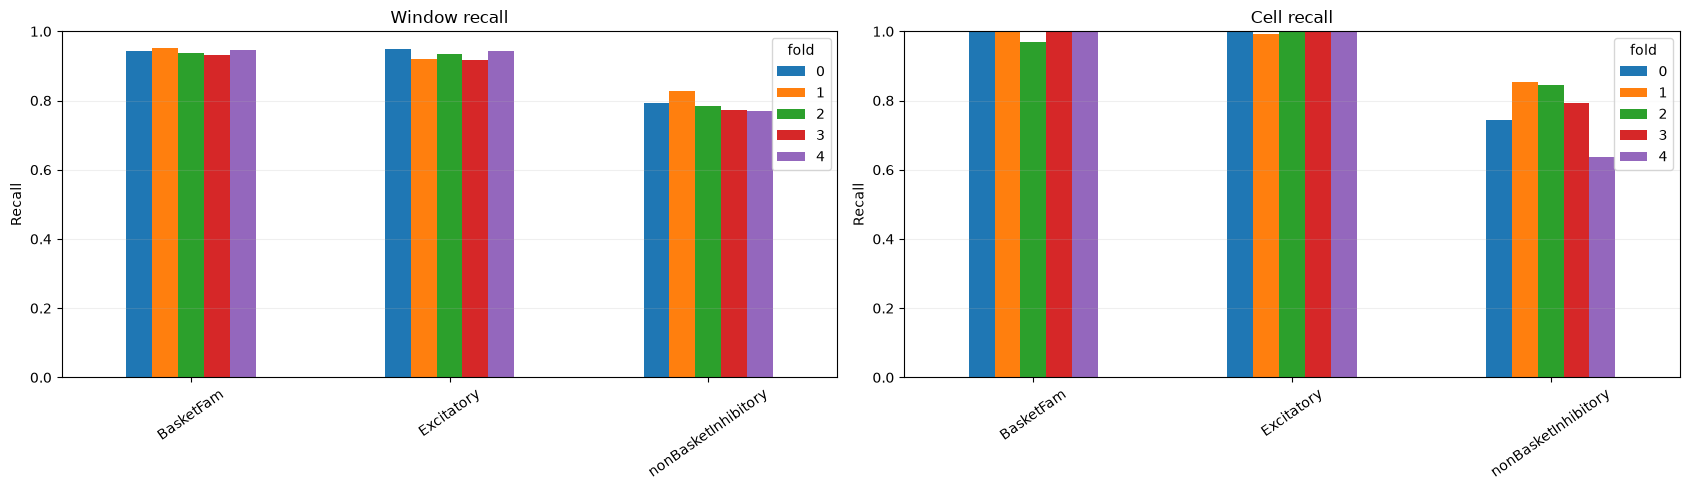

In [5]:
if payloads:
    classes = next(iter(payloads.values()))['classes']
    assert all(p['classes'] == classes for p in payloads.values()), 'Class ordering differs across folds'
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    for ax, (scope, key) in zip(axes, [('window', 'window_test_metrics'), ('cell', 'test_metrics')]):
        recall = pd.DataFrame({fold: p[key]['per_class_recall'] for fold, p in payloads.items()}).reindex(classes)
        recall.columns.name = 'fold'
        support = pd.DataFrame({fold: np.asarray(p[key]['confusion_matrix']).sum(axis=1)
                                for fold, p in payloads.items()}, index=classes)
        print(f'{scope.title()} recall by fold')
        display(recall.assign(mean=recall.mean(axis=1), std=recall.std(axis=1, ddof=1)))
        print(f'{scope.title()} support by fold')
        display(support)
        recall.plot.bar(ax=ax, color=[COLORS[f] for f in recall.columns], rot=35)
        ax.set(title=f'{scope.title()} recall', ylabel='Recall', ylim=(0, 1))
        ax.grid(axis='y', alpha=.2)
    fig.tight_layout()
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')

## Confusion matrices across folds

Rows are true classes; columns are predicted classes. Each entry shows the row-normalized proportion and the raw count in parentheses. Running folds use provisional best-checkpoint results.

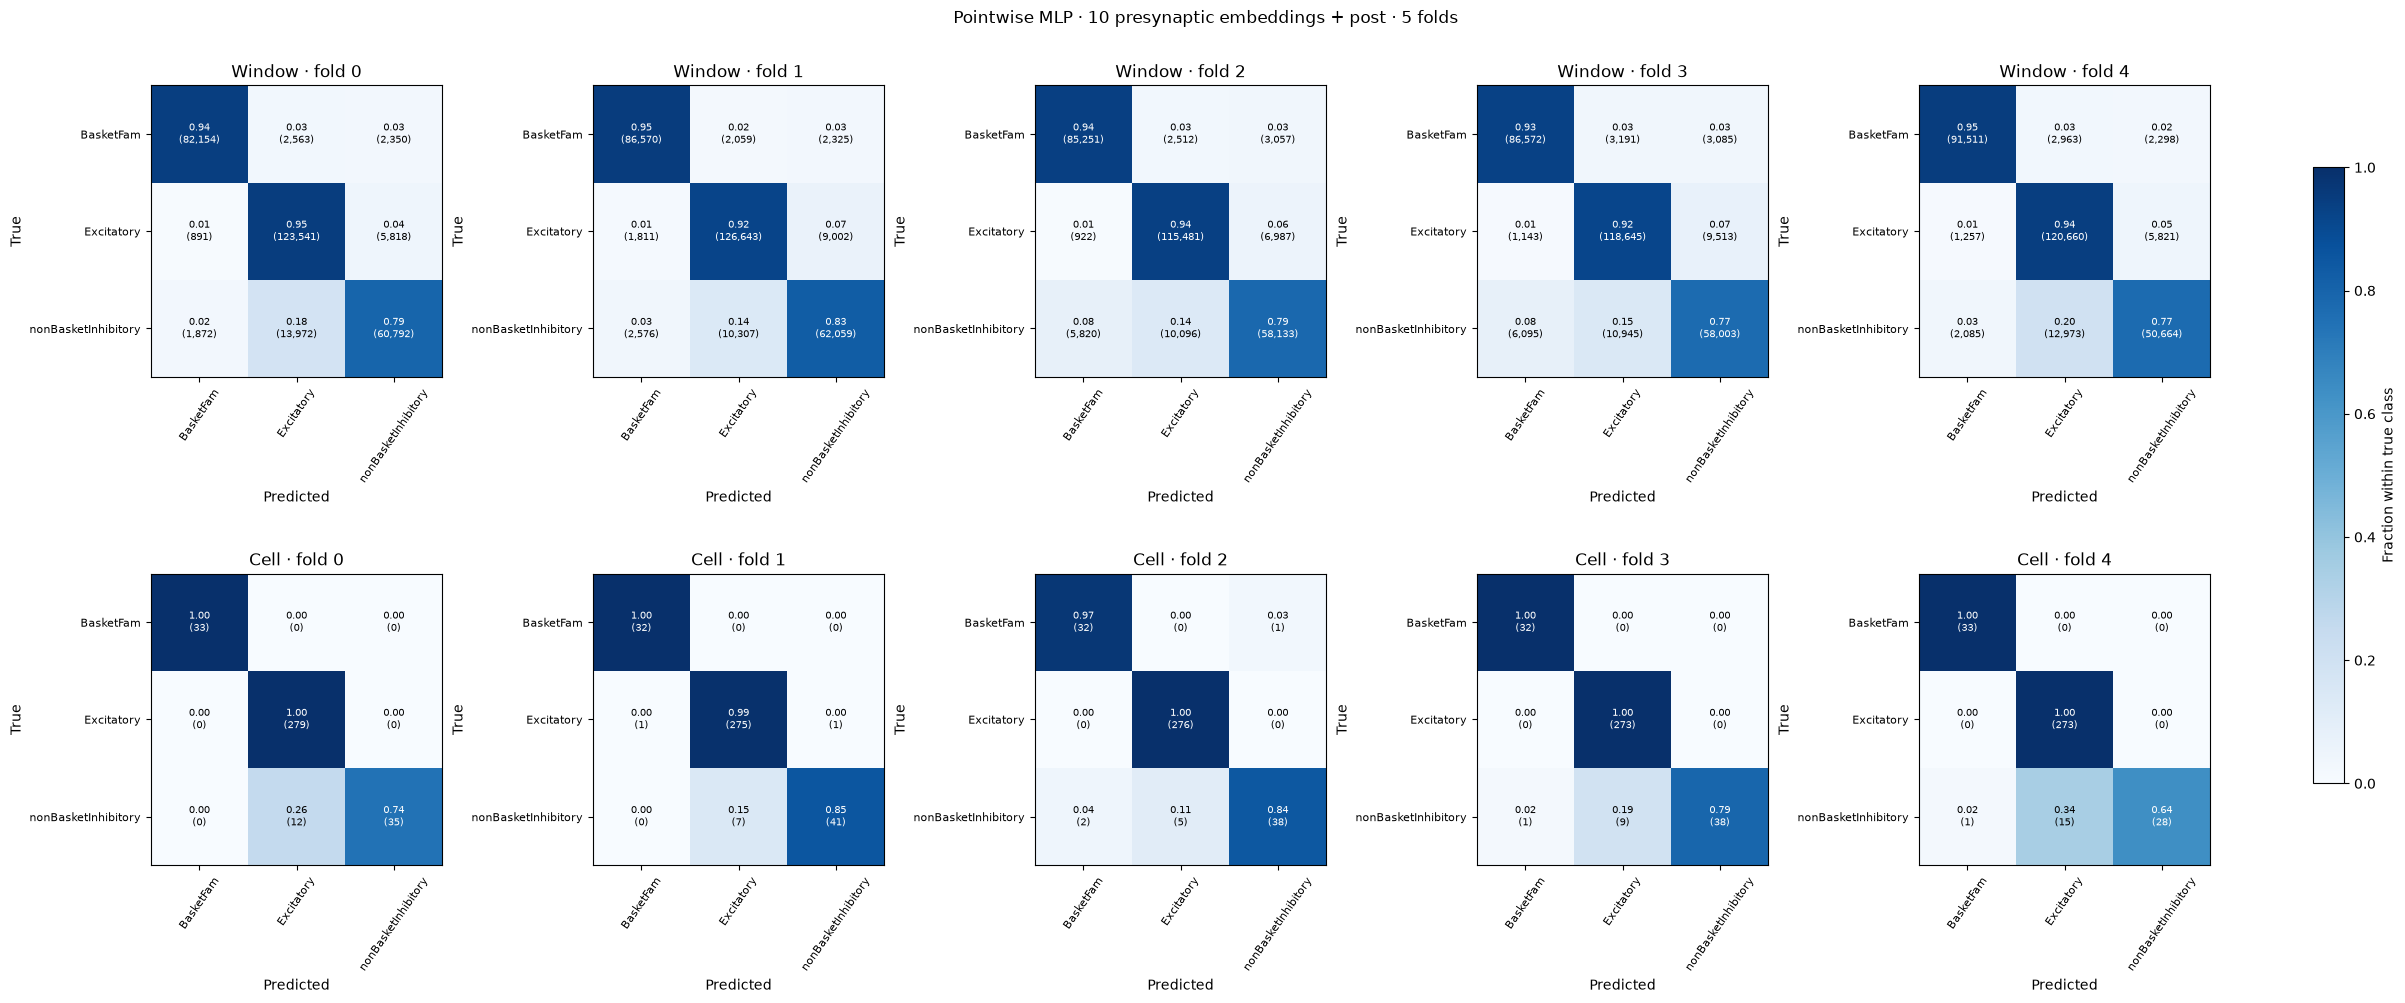

In [6]:
if payloads:
    fig, axes = plt.subplots(2, 5, figsize=(24, 10), layout='constrained')
    for row, (scope, key) in enumerate([('Window', 'window_test_metrics'), ('Cell', 'test_metrics')]):
        for fold in FOLDS:
            ax = axes[row, fold]
            if fold not in payloads:
                ax.set_title(f'{scope} · fold {fold}: unavailable')
                ax.axis('off')
                continue
            counts = np.asarray(payloads[fold][key]['confusion_matrix'])
            totals = counts.sum(axis=1, keepdims=True)
            normalized = np.divide(counts, totals, out=np.zeros_like(counts, dtype=float), where=totals != 0)
            im = ax.imshow(normalized, vmin=0, vmax=1, cmap='Blues')
            for (i, j), value in np.ndenumerate(normalized):
                ax.text(j, i, f'{value:.2f}\n({counts[i,j]:,})', ha='center', va='center', fontsize=7,
                        color='white' if value > .5 else 'black')
            ax.set(title=f'{scope} · fold {fold}', xticks=range(len(classes)), yticks=range(len(classes)),
                   xticklabels=classes, yticklabels=classes, xlabel='Predicted', ylabel='True')
            ax.tick_params(axis='x', rotation=55, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
    fig.colorbar(im, ax=axes, shrink=.7, label='Fraction within true class')
    fig.suptitle(MODEL)
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')